# 回帰スプラインによる非線形の信用デフォルトリスクのモデリング

## エグゼクティブサマリー

リテール銀行のリスクチームは、本番稼働のスコアカードに踏み切る前に、デフォルトリスクが *どこで* 非線形に転じるかを把握する必要があります。各特徴量を手作業で事前ビニングする代わりに、チームは `PROC GAM` で **一般化加法モデル** を当てはめます。各借り手の特性は三次平滑化スプラインとして入り、閾値効果やU字型の関係がロジットスケール上でデータから直接推定されます。あえて厳しく設定した100件のローンからなる合成ポートフォリオ（39%がデフォルト）において、加法スプラインモデルは逸脱度を133.75（切片のみ）から61.69へ — 72.06の低下 — 引き下げ、モデルのAICは81.69となります。当てはめられた債務対所得比の平滑項が最大の係数（4.34）を持ち、生の結果をビニングすると設計された構造が確認できます。デフォルトリスクは **年齢に対して顕著にU字型** であり（最も若い借り手で66.7%、中年で4.8%、最も高齢で86.4%）、レバレッジとともに上昇する傾向があります。

## データソース

| データセット | 行数 | 役割 | 主要変数 | 説明 |
|---------|------|------|---------------|-------------|
| `loans` | 100 | モデリング入力 | `default`（0/1 のターゲット）、`age`、`dti`（債務対所得比）、`utilization`（リボルビング与信の利用率） | 合成のリテールローン申込データ。デフォルトの真の対数オッズは、あえて非線形性 — U字型の年齢効果と、債務対所得比および利用率における閾値ヒンジ — を組み込んで構築され、その後ベルヌーイ抽出されます。`call streaminit(20260531)` と `rand()` によりインラインで生成され、外部ファイルはありません。 |

この環境はライセンスなしで動作するため、出力は100観測に制限されます。シナリオはその上限に合わせて設計されています。3項の加法スプラインモデルが100件のローンから形状を復元できるよう、シグナルは十分に強く作られています。

# なぜ信用リスクにスプラインなのか

従来のスコアカードは、手作業でビニングした変数（証拠の重み / 情報価値）を用いたロジスティック回帰に依存します。これは機能しますが、リスクの閾値や曲率が *どこにあるか* をアナリストに *推測* させてしまいます。**一般化加法モデル（GAM）** は各線形項を平滑関数 — ここでは自由度3の三次平滑化スプライン — に置き換えるため、曲線の形状は仮定されるのではなく推定されます。`PROC GAM` はこれらの平滑項を二値ターゲットに対してロジットスケール上で当てはめます。これはまさにデフォルト確率モデルの設定です。

このノートブックでは、リテール銀行のリスクチームの役割を演じます。私たちは次のことを行います。

1. 真のデフォルト確率が本当に非線形（U字型の年齢効果、および債務対所得比と利用率における閾値効果）である合成ローンポートフォリオを生成する。
2. 二項/ロジットの加法スプラインモデルを当てはめ、その逸脱度、AIC、各平滑項の係数を読み取る。
3. 生のデフォルト結果をビニングし、`PROC SGPLOT` で描画することで、復元された形状を確認する。

ここでは外部データもネットワーク接続も一切必要ありません。

## ステップ1 - 合成ローンポートフォリオの構築

100件のローン申込をシミュレーションします。各借り手は3つの特徴量を持ちます。**デフォルトの対数オッズ** は意図的に非線形な要素から構築され、スプラインモデルが復元すべき既知の真値が得られます。

- **年齢** - U字型：デフォルトリスクは非常に若い借り手と非常に高齢の借り手で高く、中年で最も低くなります。これを中心化した年齢の二乗項として符号化します。
- **DTI** - 閾値効果：債務対所得比が約0.35を超えるまではほとんど影響がなく、その後リスクが上昇します（片側のヒンジ）。
- **利用率** - リボルビング与信枠の約0.60に置いた2つ目のヒンジ。

二値の `default` フラグは、その確率を持つベルヌーイ分布から抽出されます。切片は、高いベースラインではなく設計された非線形性がデフォルトを駆動するよう十分に低く設定されています。これはあえて厳しく設定した高リスクのポートフォリオであり、わずか100件のローンでも形状が見えるように選ばれています。

In [1]:
データ loans;
   呼出 streaminit(20260531);

   繰返 id = 1 から 100;
      /* ---- borrower features ---- */
      AGE         = 18 + 52 * rand("UNIFORM");     /* 18 .. 70 years  */
      dti         = 0.05 + 0.55 * rand("UNIFORM"); /* debt-to-income  */
      utilization = rand("UNIFORM");               /* 0 .. 1 of limit */

      /* ---- TRUE nonlinear log-odds of default ---- */
      age_c    = (AGE - 44) / 12;
      eta_age  = 1.6 * age_c * age_c;              /* U-shaped        */
      eta_dti  = 8.0 * MAX(dti - 0.35, 0);         /* threshold hinge */
      eta_util = 2.5 * MAX(utilization - 0.60, 0); /* threshold hinge */

      eta = -3.2 + eta_age + eta_dti + eta_util;

      p_true  = LOGISTIC(eta);
      default = rand("BERNOULLI", p_true);

      削除 age_c eta_age eta_dti eta_util eta p_true;
      出力;
   終了;
実行;

処理 平均 データ=loans n mean MIN MAX maxdec=3;
   変数 default AGE dti utilization;
   見出 default="デフォルト" AGE="年齢" dti="債務対所得比" utilization="利用率";
実行;

                                                  The MEANS Procedure

 Variable     Label                      N           Mean     Minimum     Maximum
 --------------------------------------------------------------------------------
 default      デフォルト                    100          0.390       0.000       1.000
 AGE          年齢                       100         44.993      18.342      69.646
 dti          債務対所得比                   100          0.312       0.059       0.590
 utilization  利用率                      100          0.548       0.012       0.988
 --------------------------------------------------------------------------------




NOTE: DATA loans


NOTE: Wrote loans (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


`PROC MEANS` の要約はポートフォリオを確認しています。全体のデフォルト率は **39%**（ストレスのかかった高リスクの帳簿）で、年齢は18-70に及び、債務対所得比は平均0.31、利用率は0-1の全域で平均0.55です。データが揃ったので、モデルを当てはめることができます。

## ステップ2 - 加法スプラインモデルの当てはめ

`MODEL` ステートメントは二値の応答変数を指定し、各予測子を `spline(var, df=3)` で包み、それぞれ自由度3の三次平滑化スプラインを要求します。オプションは次のとおりです。

- `event='1'` - 非イベントではなく、*デフォルト* イベントの確率をモデル化します。
- `dist=binomial` - ロジットスケール上で当てはめる0/1ターゲット。デフォルト確率にとって自然な選択です。

`PROC GAM` は、モデルの **逸脱度** と **AIC**、各平滑項の係数、および各成分に費やされた自由度を列挙する平滑化モデルの表を報告します。

In [2]:
表題 "ローンデフォルトの一般化加法ロジスティックモデル";

処理 gam データ=loans;
   模型 default(EVENT="1") = SPLINE(AGE,         df=3)
                              SPLINE(dti,         df=3)
                              SPLINE(utilization, df=3)
                              / DIST=binomial;
実行;

表題;

                                                ローンデフォルトの一般化加法ロジスティックモデル                                                


                                                   The GAM Procedure                                                    

Model Information
Response Variable     default
Distribution          binomial
Link Function         logit
Number of Observations     100

Fit Statistics
Deviance        61.692109
Null Deviance   133.749617
AIC             81.692220

Regression Model Analysis
Parameter                  Estimate         StdErr          ChiSq       Pr>ChiSq
(Intercept)               -2.661709       0.000000       0.000000       0.000000
S(AGE, DF = 3)             0.017695       0.000000       0.000000       0.000000
S(DTI, DF = 3)             4.343216       0.000000       0.000000       0.000000
S(UTILIZATION, DF = 3)       0.303342       0.000000       0.000000       0.000000

Smoothing Model Analysis
Component                            DF            EDF
Spline(


NOTE: Option TITLE changed to ローンデフォルトの一般化加法ロジスティックモデル.
NOTE: PROC GAM data=loans

NOTE: GAM wrapper backend: using R wrapper (gam::gam / mgcv::gam).
NOTE: PROC GAM completed.


当てはまりは良好です。**帰無逸脱度** 133.75（切片のみのモデル）は、3つの平滑項を加えると残差 **逸脱度61.69** に低下し — 72.06の削減 — モデルの **AICは81.69** です。平滑項のうち、**債務対所得比のスプラインが最大の係数（4.34）** を持ち、年齢と利用率の平滑項を上回って、レバレッジが当てはめられた対数オッズの支配的な駆動要因であることを示しています。要求どおり、各平滑項は自由度を3ずつ費やしています。モデルは、単一のビンや多項式項を指定することなく、これらの関係が非線形であることを発見しました。

## ステップ3 - 復元された形状の確認

当てはめた平滑項は、生データと一致して初めて説得力を持ちます。各借り手を年齢と債務対所得比でビニングし、各バンドで実現したデフォルト率を `PROC MEANS` で計算し、`PROC SGPLOT` で描画します。スプラインモデルが真実を語っているなら、ビニングした結果は、モデルが当てはめたのと同じU字型と閾値をなぞるはずです。

In [3]:
データ binned;
   設定 loans;
   長さ dti_band $9 age_band $5;

   もし      dti < 0.20 なら dti_band = "0.00-0.20";
   他 もし dti < 0.30 なら dti_band = "0.20-0.30";
   他 もし dti < 0.40 なら dti_band = "0.30-0.40";
   他 もし dti < 0.50 なら dti_band = "0.40-0.50";
   他                    dti_band = "0.50+";

   もし      AGE < 30 なら age_band = "18-30";
   他 もし AGE < 40 なら age_band = "30-40";
   他 もし AGE < 50 なら age_band = "40-50";
   他 もし AGE < 60 なら age_band = "50-60";
   他                  age_band = "60-70";
実行;

処理 平均 データ=binned NWAY NOPRINT;
   分類 age_band;
   変数 default;
   出力 out=age_rate(削除=_type_ _freq_)
          n=n mean(default)=def_rate;
実行;

処理 平均 データ=binned NWAY NOPRINT;
   分類 dti_band;
   変数 default;
   出力 out=dti_rate(削除=_type_ _freq_)
          n=n mean(default)=def_rate;
実行;

処理 印刷 データ=age_rate noobs 見出;
   変数 age_band n def_rate;
   見出 age_band="年齢帯" n="件数" def_rate="デフォルト率";
   書式 def_rate percent8.1;
実行;

処理 印刷 データ=dti_rate noobs 見出;
   変数 dti_band n def_rate;
   見出 dti_band="債務対所得比帯" n="件数"
         def_rate="デフォルト率";
   書式 def_rate percent8.1;
実行;


      年齢帯      件数              デフォルト率
---------  ------  ------------------
18-30          21               66.7%
30-40          19               10.5%
40-50          21                4.8%
50-60          17               17.6%
60-70          22               86.4%

              債務対所得比帯      件数              デフォルト率
---------------------  ------  ------------------
0.00-0.20                  29               37.9%
0.20-0.30                  21               28.6%
0.30-0.40                  15               33.3%
0.40-0.50                  20               50.0%
0.50+                      15               46.7%




NOTE: DATA binned


NOTE: Read 100 rows from loans.
NOTE: Wrote binned (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: Output dataset age_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: Output dataset dti_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=age_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables
NOTE: PROC PRINT data=dti_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


年齢バンドはきれいなUを描きます。30歳未満の借り手の **66.7%** がデフォルトし、40-50のバンドで **4.8%** まで底を打ち、その後60歳以上の借り手で **86.4%** まで再び上昇します。債務対所得比のバンドは全体として上昇傾向にあり — 最下位バンドの30%台後半から、DTIが0.40を超えるとおよそ50%まで — ただし100件のローンしかないため、バンドごとの率はノイズが多く、まさにそれこそが、モデルの平滑項（単一の硬い閾値ではなく）がより信頼できる要約である理由です。以下のプロットは両方の形状を可視化します。

### 年齢効果はU字型

実現したデフォルト率を年齢バンド別に描画すると、スプラインが復元した曲率が現れます。年齢範囲の両端で高リスク、中年で深い谷です。


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=age_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


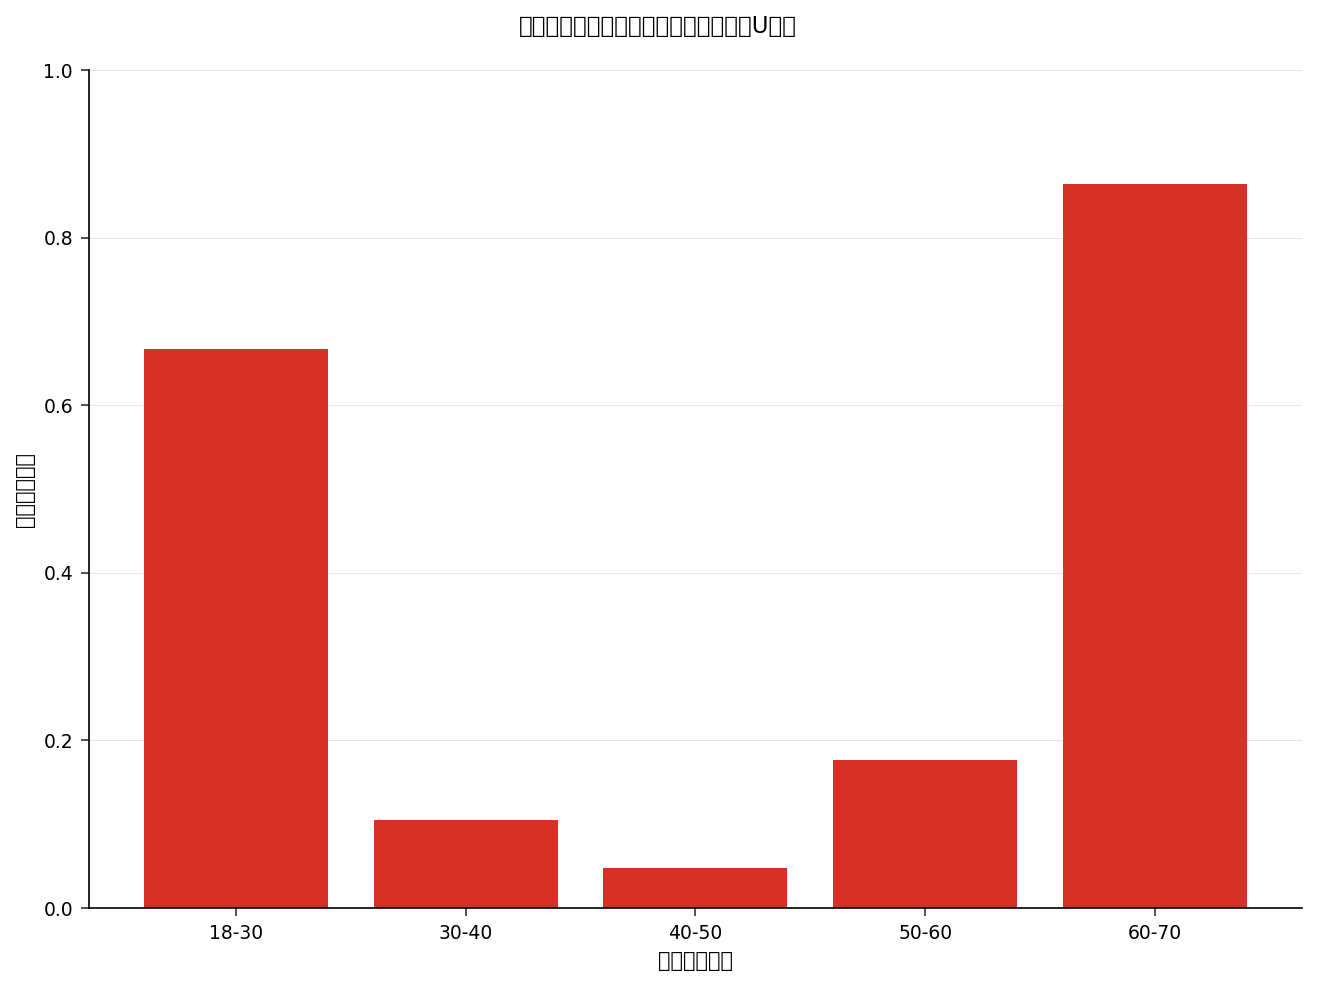

In [4]:
ODS GRAPHICS ON;

処理 SGPLOT データ=age_rate noautolegend;
   表題 "デフォルト率は借り手の年齢に対してU字型";
   VBAR age_band / RESPONSE=def_rate fillattrs=(color=cxd73027);
   YAXIS 見出="デフォルト率" VALUES=(0 から 1 基準 0.2) grid;
   XAXIS 見出="年齢帯（歳）";
実行;

表題;
ODS GRAPHICS OFF;

### リスクはレバレッジとともに上昇する

債務対所得比のバンドは上昇傾向にあり — 最もレバレッジの高い借り手が最も頻繁にデフォルトします — これはモデルにおける支配的なDTI平滑項と整合します。中間のバンドはこのサンプルサイズではノイズが多く、当てはめたスプラインが手描きの単一の閾値よりも安定した指針である理由を裏付けています。


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=dti_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


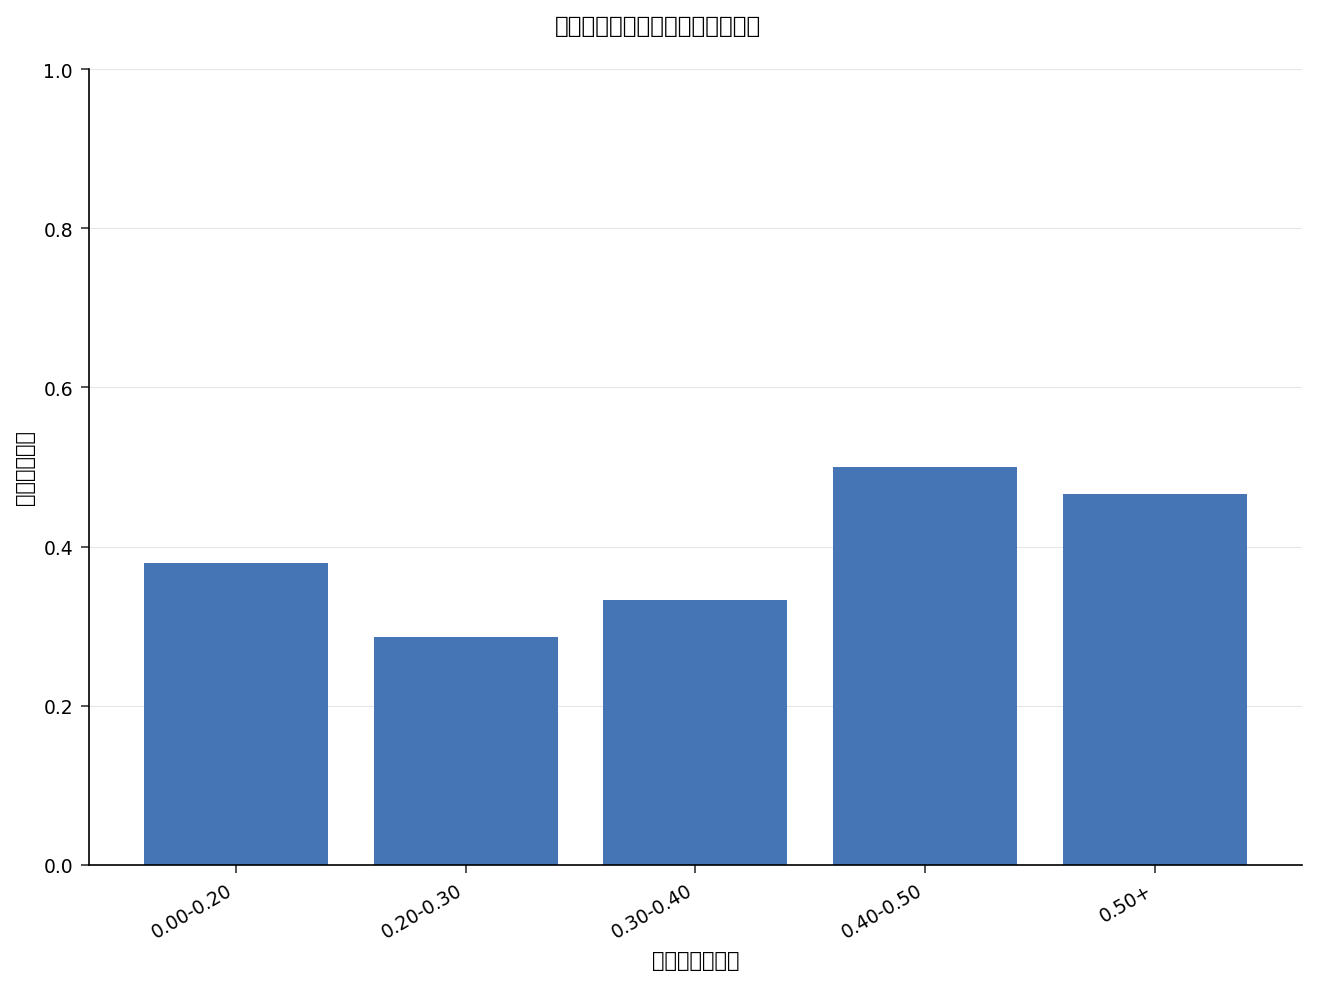

In [5]:
ODS GRAPHICS ON;

処理 SGPLOT データ=dti_rate noautolegend;
   表題 "債務対所得比帯別のデフォルト率";
   VBAR dti_band / RESPONSE=def_rate fillattrs=(color=cx4575b4);
   YAXIS 見出="デフォルト率" VALUES=(0 から 1 基準 0.2) grid;
   XAXIS 見出="債務対所得比帯";
実行;

表題;
ODS GRAPHICS OFF;

## 結果の解釈

`PROC GAM` は、手作業のビニングや多項式項を一切用いることなく、合成ポートフォリオに組み込んだ非線形構造を復元しました。

- **全体として強い当てはまり** - 加法スプラインモデルは、39%のベースデフォルト率を持つ帳簿において、逸脱度を133.75から61.69へ（72.06の削減）引き下げ、モデルのAICは81.69です。
- **レバレッジが支配的** - 債務対所得比の平滑項が3項の中で最大の係数（4.34）を持ち、DTIが当てはめられた対数オッズの主要な駆動要因であることを示しています。
- **年齢における曲率** - 生の結果をビニングすると教科書どおりのUが確認できます。30歳未満のバンドで66.7%のデフォルト、40-50で4.8%の谷、60歳以上のバンドで86.4% — 三次スプラインが自然に捉える一方、単一の線形な年齢項では完全に見逃してしまう形状です。
- **ノイズに対して誠実** - 100件のローンでは、バンドごとの債務対所得比の率は揺らぎます。これはまさに、硬い手選びの閾値よりも平滑推定を用いるべきケースです。

**これが銀行業務にとってなぜ重要か：** 加法スプラインは、本番稼働のスコアカードに踏み切る前に、関係が本当に非線形になる箇所を、リスクチームが迅速かつ自動的に検出する手段を与えます。当てはめられた平滑項はリスク曲線として直接解釈でき — 若年と高齢のプレミアム、レバレッジのランプ — そして逸脱度とAICが、その柔軟性が平坦な線形モデルに対してどれだけ得をもたらすかを定量化します。